# MLP
Notebook separado para treino de MLP (RNA) e mapa discretizado por percentil.


In [1]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from keras import Sequential, Input
from keras.layers import Dense
from sklearn.model_selection import KFold

modelos = {"RNA": []}
altitude = []
data_folder = "../data/"
altitude.append(pd.read_csv(data_folder + "Altitude_2025-10-14T20_07_43.980Z.csv"))
altitude.append(pd.read_csv(data_folder + "Altitude_2025-10-14T20_15_03.183Z.csv"))


In [2]:
def discretize_by_percentile(values, n_divisions=3):
    if n_divisions <= 0:
        raise ValueError("n_divisions deve ser maior que zero.")
    arr = np.asarray(np.ma.filled(values, np.nan), dtype=float)
    flat = arr.reshape(-1)
    valid_mask = np.isfinite(flat)
    if valid_mask.sum() == 0:
        return np.full(arr.shape, np.nan)
    valid_values = flat[valid_mask]
    quantiles = np.linspace(0, 1, int(n_divisions) + 1)
    edges = np.nanquantile(valid_values, quantiles)
    edges = np.unique(edges)
    classes_flat = np.full(flat.shape, np.nan)
    if len(edges) <= 1:
        classes_flat[valid_mask] = 1
    else:
        bins = np.digitize(valid_values, edges[1:-1], right=True) + 1
        classes_flat[valid_mask] = bins.astype(float)
    return classes_flat.reshape(arr.shape)


In [3]:
def rna(data: pd.DataFrame, number_intermediary_layers: list = None, activation="relu"):
    if number_intermediary_layers is None:
        number_intermediary_layers = [1]
    model = Sequential()
    model.add(Input(shape=(2,)))
    if len(number_intermediary_layers) == 0:
        name = "sem layer"
    else:
        name = f"layer oculto: {number_intermediary_layers} - funcao: {activation}"
        for layer_size in number_intermediary_layers:
            if layer_size <= 0:
                raise ValueError(f"Layer size must be a positive integer. Received: {layer_size}")
            model.add(Dense(layer_size, activation=activation))
    model.add(Dense(1, activation="linear"))
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    x, z = data.iloc[:, :-1], data.iloc[:, -1]
    history = model.fit(x, z, epochs=1000, batch_size=32, validation_split=0.2, verbose=0)
    print(history)
    loss, mae = model.evaluate(x, z, verbose=0)
    print(name)
    modelos["RNA"].append(model)
    print(f"Erro medio absoluto: {mae:.4f} - Loss: {loss:.4f}")
    return model


In [4]:
def create_grid(data: pd.DataFrame, resolution: float, model, n_divisions: int = 3):
    x = data.iloc[:, 0].to_numpy()
    y = data.iloc[:, 1].to_numpy()
    min_x, max_x = x.min(), x.max()
    min_y, max_y = y.min(), y.max()
    grid_x = np.arange(min_x, max_x + 1e-8, resolution)
    grid_y = np.arange(min_y, max_y + 1e-8, resolution)
    preds = []
    for xi in grid_x:
        batch = np.column_stack([np.full(grid_y.shape, xi), grid_y])
        y_pred = model.predict(batch)
        y_pred = np.asarray(y_pred).reshape(-1)
        for yi, zi in zip(grid_y, y_pred):
            preds.append([xi, yi, float(zi)])
    predict_df = pd.DataFrame(preds, columns=["x", "y", "z"])
    grid_data = predict_df.pivot(index="y", columns="x", values="z")
    grid_disc = discretize_by_percentile(grid_data.to_numpy(), n_divisions=n_divisions)
    n_classes = int(np.nanmax(grid_disc)) if np.isfinite(grid_disc).any() else 1
    cmap = sns.color_palette("viridis", n_colors=max(n_classes, 1))
    plt.figure(figsize=(8, 6))
    sns.heatmap(grid_disc, cmap=cmap, vmin=1, vmax=max(n_classes, 1), cbar_kws={"label": "Classe (percentil)"})
    plt.title(f"Mapa discretizado da previsao da RNA ({n_divisions} divisoes)")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.tight_layout()
    plt.show()
    return predict_df


In [5]:
def cross_validate_mlp(data: pd.DataFrame, n_splits=5, number_intermediary_layers: list = None, activation="relu"):
    x, z = data.iloc[:, :-1], data.iloc[:, 2]
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    mae_scores = []
    loss_scores = []
    if number_intermediary_layers is None:
        number_intermediary_layers = []
    for train_index, test_index in kf.split(x):
        x_train, x_test = x.iloc[train_index], x.iloc[test_index]
        z_train, z_test = z.iloc[train_index], z.iloc[test_index]
        model = Sequential()
        model.add(Input(shape=(2,)))
        if len(number_intermediary_layers) > 0:
            for layer_size in number_intermediary_layers:
                if layer_size <= 0:
                    raise ValueError(f"Layer size must be a positive integer. Received: {layer_size}")
                model.add(Dense(layer_size, activation=activation))
        model.add(Dense(1, activation="linear"))
        model.compile(optimizer="adam", loss="mse", metrics=["mae"])
        model.fit(x_train, z_train, epochs=1000, batch_size=32, verbose=0)
        loss, mae = model.evaluate(x_test, z_test, verbose=0)
        mae_scores.append(mae)
        loss_scores.append(loss)
    layer_description = "no hidden layers" if len(number_intermediary_layers) == 0 else f"{len(number_intermediary_layers)} hidden layers with sizes {number_intermediary_layers}"
    print(f"Model with {layer_description} and {activation} activation:")
    print(f"Average MAE: {np.mean(mae_scores):.4f} - Average Loss: {np.mean(loss_scores):.4f}")


layer oculto: [8, 8] - funcao: relu
Erro medio absoluto: 5.1691 - Loss: 39.7010
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


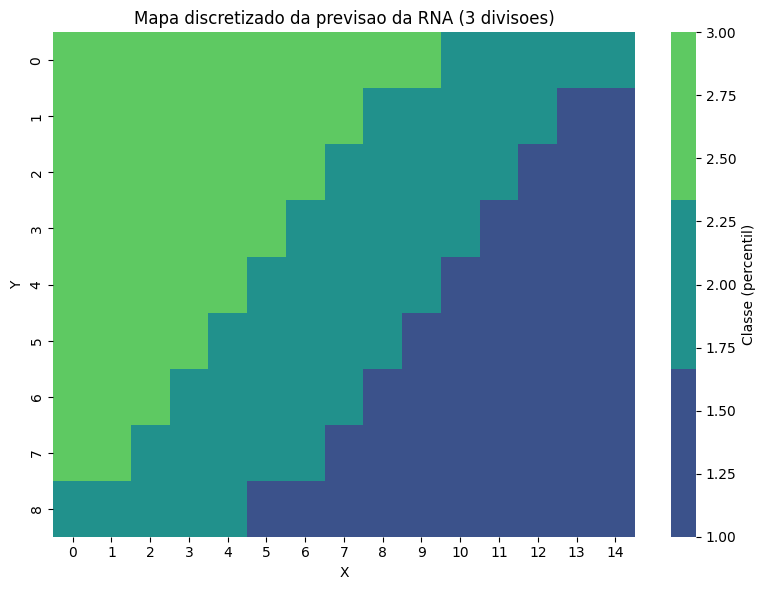

In [6]:
model = rna(altitude[0], number_intermediary_layers=[8, 8], activation="relu")
grid_df = create_grid(altitude[0], resolution=0.0005, model=model)
